In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Ready!")
#imported  libraries

Ready!


In [2]:
df = pd.read_csv("Food Ingredients and Recipe Dataset with Image Name Mapping.csv")
print("Uploaded!")
#upload the dataset to this notebook

Uploaded!


In [3]:
df.head(5)
#first 5 line

,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ..."
3,3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Preheat oven to 350°F with rack in middle. Gen...,italian-sausage-and-bread-stuffing-240559,"['1 (¾- to 1-pound) round Italian loaf, cut in..."
4,4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Stir together brown sugar and hot water in a c...,newtons-law-apple-bourbon-cocktail,"['1 teaspoon dark brown sugar', '1 teaspoon ho..."


In [4]:
df.info()
#understand the columns and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           13501 non-null  int64 
 1   Title                13496 non-null  object
 2   Ingredients          13501 non-null  object
 3   Instructions         13493 non-null  object
 4   Image_Name           13501 non-null  object
 5   Cleaned_Ingredients  13501 non-null  object
dtypes: int64(1), object(5)
memory usage: 633.0+ KB


In [5]:
print(df.shape)
#how many recipes are there?

(13501, 6)


In [6]:
df.isnull().sum()
#find the missing value

Unnamed: 0             0
Title                  5
Ingredients            0
Instructions           8
Image_Name             0
Cleaned_Ingredients    0
dtype: int64

In [7]:
df = df.dropna()
#finds and deletes rows that contain empty values

In [8]:
df.shape
#shape control again

(13493, 6)

In [9]:
df = df.drop(columns=["Unnamed: 0","Image_Name"])
#delete unnecessary colums

In [10]:
df.shape
#shape control again

(13493, 4)

In [11]:
df.describe()
#basic statistics

,Title,Ingredients,Instructions,Cleaned_Ingredients
count,13493,13493,13493,13493
unique,13302,13471,13464,13471
top,Potato Latkes,[],Place ingredients in blender in the order list...,['']
freq,5,6,5,6


In [12]:
import ast
from collections import Counter
#ast -> to access the ingredients
#Counter -> to count the ingredients

In [13]:
all_ingredients = []                  #create a list for ingredients
for row in df["Cleaned_Ingredients"]: #to navigate through "Cleaned_Ingredients" columns 
    ingre_list = ast.literal_eval(row)      #convert the text into list
    all_ingredients.extend(ingre_list)      #add to the list

In [14]:
len(all_ingredients)
#we can see how many have ingredients

148306

In [15]:
count = Counter(all_ingredients)
print(count.most_common(10))
#create a counter and we find first 10 most common ingredients in all ingredienst

[('Kosher salt', 1191), ('1/2 teaspoon salt', 663), ('Freshly ground black pepper', 618), ('1/4 teaspoon salt', 613), ('Kosher salt, freshly ground pepper', 594), ('2 tablespoons olive oil', 499), ('2 large eggs', 442), ('1 teaspoon vanilla extract', 402), ('1 teaspoon salt', 382), ('1 large egg', 374)]


In [16]:
labels, values = zip(*count.most_common(10))
#split ingredients and counts into separate lists

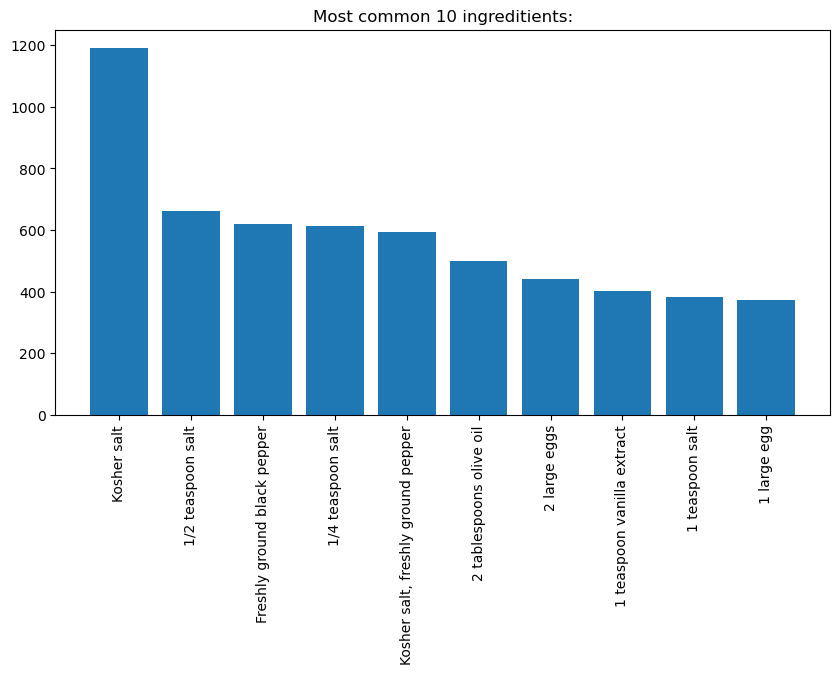

In [17]:
plt.figure(figsize = (10,5))                #set the graphic size
plt.bar(labels,values)                      #to draw a bar chart
plt.xticks(rotation=90)                     #to itilacize the material names on the x axis
plt.title("Most common 10 ingreditients:")  #title
plt.show()                                  #to show the graph

In [18]:
egg_recipes = df[df["Cleaned_Ingredients"].str.contains("egg", case = False)]
#to find recipe that include 'egg'      #check whether a certain word appears in the column
len(egg_recipes)

3723

In [19]:
df.columns

Index(['Title', 'Ingredients', 'Instructions', 'Cleaned_Ingredients'], dtype='object')

In [20]:
oven_recipes = df[df["Instructions"].str.contains("oven", case = False)]
len(oven_recipes)
#to find recipes that will ose the oven

5694

In [21]:
egg_and_oven = df[df["Cleaned_Ingredients"].str.contains("egg", case = False) 
                  & df["Instructions"].str.contains("oven", case = False)]
#to merge these two filters
len(egg_and_oven)

2504

In [22]:
egg_and_oven.to_csv("recipes_using_egg_and_oven.csv", index = False)
#to save these results as csv
print("Saved!")

Saved!


In [23]:
#user_ingredients = input("Ingredients you have: ").split(" ")
user_ingredients = ["egg", "flour", "butter"]
#get the ingredients that the user owns
#list the entered ingredients
user_ingredients

['egg', 'flour', 'butter']

In [24]:
result = df         #assign it to the result variable so as not to change the df value
for ingredient in user_ingredients:
    result = result[result["Cleaned_Ingredients"].str.contains(ingredient, case = False)]
#find the recipes that include all the ingredients we have in the dataset
len(result)

1503

In [25]:
result["Title"].head(5)
#title of first 5 recipes

42         Pumpkin Dutch Baby With Pumpkin Butter
69                        Chocolate Zucchini Cake
72               Tomato Pie With Sour Cream Crust
78    Fresh Fruit Tart With Almond Press-In Crust
81              Pear and Hazelnut Frangipane Tart
Name: Title, dtype: object

In [26]:
matches = []        #list to store matching recipes
for index,row in df.iterrows():    #iterate through each recipe
    count = 0
    for ingredient in user_ingredients:   #check each ingredient 
        if ingredient in row["Cleaned_Ingredients"]:
            count += 1      #if ingredient found in recipe, increase count
    if count >= 1:
        matches.append((row["Title"], count))
    #if at least one ingredient matches, add recipe title and match count to list
matches

[('Miso-Butter Roast Chicken With Acorn Squash Panzanella', 2),
 ('Crispy Salt and Pepper Potatoes', 1),
 ('Italian Sausage and Bread Stuffing', 2),
 ("Newton's Law", 1),
 ('Apples and Oranges', 1),
 ('Spiced Lentil and Caramelized Onion Baked Eggs', 2),
 ('Butternut Squash and Apple Soup', 1),
 ('Chicken and Rice With Leeks and Salsa Verde', 1),
 ('Gorditas con Camarones', 2),
 ('Chicken and Potato Gratin With Brown Butter Cream', 1),
 ('Maple and Chile Roasted Squash With Quinoa Tabouli', 1),
 ('Sloppy Joe Shirred Eggs With Spinach', 1),
 ('Miso-Squash Ramen', 1),
 ('Baigan Chokha', 1),
 ('Shrimp Creole', 1),
 ('Chicken Pelau', 1),
 ('Our Favorite Creamy Mashed Potatoes', 1),
 ('Creole Cream Cheesecake With Caramel-Apple Topping', 2),
 ('Creole Cream Cheese', 1),
 ('Buss Up Shut (Paratha Roti)', 2),
 ('Best Deviled Eggs', 1),
 ('Pumpkin Dutch Baby With Pumpkin Butter', 3),
 ('Old-Fashioned Scalloped Potatoes', 2),
 ('Pita', 1),
 ('Drunk Apricot Shito (Ghanaian Hot Pepper Sauce)', 1),

In [27]:
sorted_matches = sorted(matches, key=lambda x: x[1], reverse = True)
sorted_matches[:10]
#sort the list of matches and show the first 10 recipes

[('Pumpkin Dutch Baby With Pumpkin Butter', 3),
 ('Chocolate Zucchini Cake', 3),
 ('Tomato Pie With Sour Cream Crust', 3),
 ('Fresh Fruit Tart With Almond Press-In Crust', 3),
 ('Pear and Hazelnut Frangipane Tart', 3),
 ('Peanut Butter Brookies', 3),
 ('Stone Fruit Custard Tart', 3),
 ('Double Ripple Ice Cream Cake', 3),
 ('Savory Gruyère Bread With Ham', 3),
 ('Mississippi Corn Pudding', 3)]

In [28]:
matches_two = []
for index, row in df.iterrows():
    count = 0
    missing_ingredients = []
    for ingredient in user_ingredients:
        if ingredient in row["Cleaned_Ingredients"]:
            count += 1
        else:
            missing_ingredients.append(ingredient)  
        #create a list for missing ingredients and add the missing ingredients to the list 
    if count >= 1:
        matches_two.append((row["Title"], count, missing_ingredients))
    #if at least one ingredient matches, add recipe title, match count and messing ingredients to list
matches_two

[('Miso-Butter Roast Chicken With Acorn Squash Panzanella', 2, ['egg']),
 ('Crispy Salt and Pepper Potatoes', 1, ['flour', 'butter']),
 ('Italian Sausage and Bread Stuffing', 2, ['flour']),
 ("Newton's Law", 1, ['egg', 'flour']),
 ('Apples and Oranges', 1, ['egg', 'flour']),
 ('Spiced Lentil and Caramelized Onion Baked Eggs', 2, ['flour']),
 ('Butternut Squash and Apple Soup', 1, ['egg', 'flour']),
 ('Chicken and Rice With Leeks and Salsa Verde', 1, ['egg', 'flour']),
 ('Gorditas con Camarones', 2, ['egg']),
 ('Chicken and Potato Gratin With Brown Butter Cream', 1, ['egg', 'flour']),
 ('Maple and Chile Roasted Squash With Quinoa Tabouli', 1, ['egg', 'flour']),
 ('Sloppy Joe Shirred Eggs With Spinach', 1, ['flour', 'butter']),
 ('Miso-Squash Ramen', 1, ['egg', 'flour']),
 ('Baigan Chokha', 1, ['flour', 'butter']),
 ('Shrimp Creole', 1, ['egg', 'flour']),
 ('Chicken Pelau', 1, ['egg', 'flour']),
 ('Our Favorite Creamy Mashed Potatoes', 1, ['egg', 'flour']),
 ('Creole Cream Cheesecake Wit

In [29]:
sorted_matches_two = sorted(matches_two, key=lambda x: x[1], reverse = True)
sorted_matches_two[-1]
#sort the list of matches_two and show the last recipe

('Spanakopita', 1, ['egg', 'flour'])

In [30]:
#search_ingredients = input("The name of the searched recipe: ")
title_results = df[df["Title"].str.contains("cake", case = False)]
len(title_results)
#find the how many recipe's name(title) have 'cake'

758

In [31]:
#now let's combine this with the material filter
#let it include 'cake' in the name and also match the user's ingredients
result_filtered = title_results
for ingredient in user_ingredients:
    result_filtered = result_filtered[result_filtered["Cleaned_Ingredients"].str.contains(ingredient, case = False)]
len(result_filtered)

451

In [32]:
result_filtered["Title"].head()
#show the first 5 recipes

69                               Chocolate Zucchini Cake
111                         Double Ripple Ice Cream Cake
164    Very Red Velvet Cake With Cream Cheese Icing a...
167                              Strawberry Coconut Cake
169                                            Tea Cakes
Name: Title, dtype: object

In [33]:
import json

In [34]:
json_results = []
for title, count, missing in sorted_matches_two:
    json_results.append({"title": title, "match_count": count, "missing_ingredients": missing})
json_results[:3]
#convert it to JSON format to store the information in an organized and readable way

[{'title': 'Pumpkin Dutch Baby With Pumpkin Butter',
  'match_count': 3,
  'missing_ingredients': []},
 {'title': 'Chocolate Zucchini Cake',
  'match_count': 3,
  'missing_ingredients': []},
 {'title': 'Tomato Pie With Sour Cream Crust',
  'match_count': 3,
  'missing_ingredients': []}]

In [35]:
with open("results.json", "w") as f:        #open the file
    json.dump(json_results, f, indent=2)    #save the file
#create a JSON file and save the json_results values here

In [36]:
def filter_by_ingredients(ingredients):   #filter recipes by a list of ingredients
    result = df   #start with the full dataset
    for ingredient in ingredients:   #filter for each ingredient
        result = result[result["Cleaned_Ingredients"].str.contains(ingredient, case = False)]
        # narrow down results
    return result   #return filtered recipes

In [37]:
filter_by_ingredients(user_ingredients)

,Title,Ingredients,Instructions,Cleaned_Ingredients
42,Pumpkin Dutch Baby With Pumpkin Butter,"['3 large eggs, room temperature', '1 (15-ounc...",Place an 8-inch ovenproof skillet or cast-iron...,"['3 large eggs, room temperature', '1 (15-ounc..."
69,Chocolate Zucchini Cake,"['2 1/4 cups sifted all purpose flour', '1/2 c...",Preheat oven to 325°F. Butter and flour 13 x 9...,"['2 1/4 cups sifted all purpose flour', '1/2 c..."
72,Tomato Pie With Sour Cream Crust,"['2 cups all-purpose flour, plus a little extr...","Preheat the oven to 375°F.\nIn a large, wide b...","['2 cups all-purpose flour, plus a little extr..."
78,Fresh Fruit Tart With Almond Press-In Crust,"['2 large egg yolks', '1 cup all-purpose flour...",Place a rack in the middle of oven; preheat to...,"['2 large egg yolks', '1 cup all-purpose flour..."
81,Pear and Hazelnut Frangipane Tart,"['1 cup hazelnuts, toasted, loose skins rubbed...",Preheat oven to 350°F.\nPulse hazelnuts with 1...,"['1 cup hazelnuts, toasted, loose skins rubbed..."
...,...,...,...,...
13489,Raspberry Jam Tart with Almond Crumble,"['2 cups sliced natural almonds', '2/3 cup sug...",Preheat oven to 400°F.\nReserve 1/4 cup almond...,"['2 cups sliced natural almonds', '2/3 cup sug..."
13492,Cornmeal Pancakes with Honey-Pecan Butter,['1/2 cup (1 stick) unsalted European-style bu...,"Using electric mixer, beat 1/2 cup butter, hon...",['1/2 cup (1 stick) unsalted European-style bu...
13493,Chocolate Heart Layer Cake with Chocolate-Cinn...,"['4 tablespoons unsalted butter, melted', '1/3...",Preheat oven to 400°F. Place 8x8x2-inch heart-...,"['4 tablespoons unsalted butter, melted', '1/3..."
13494,Ginger-Pecan Roulade with Honey-Glazed Pecans,"['1/2 stick (1/4 cup) unsalted butter, melted,...",Preheat oven to 350°F. Line bottom and sides o...,"['1/2 stick (1/4 cup) unsalted butter, melted,..."


In [38]:
def filter_by_name(keyword):   #filter recipes by a keyword in the title
    return df[df["Title"].str.contains(keyword, case = False)]   #return recipes whose title contains the keyword

In [39]:
filter_by_name("cake")

,Title,Ingredients,Instructions,Cleaned_Ingredients
22,Chhena Poda (Spiced Cheesecake),"['Ghee, for the cake pan', '8 ounces paneer, p...",Preheat the oven to 350°F. Butter a 9-inch non...,"['Ghee, for the cake pan', '8 ounces paneer, p..."
36,Creole Cream Cheesecake With Caramel-Apple Top...,['2 cups graham cracker crumbs (about 16 whole...,Make the crust. Preheat the oven to 375°F. In ...,['2 cups graham cracker crumbs (about 16 whole...
68,Frozen Avocado Cake,"['Softened butter (for the pan)', '8 whole gra...",Preheat the oven to 350°F (180°C). Lightly but...,"['Softened butter (for the pan)', '8 whole gra..."
69,Chocolate Zucchini Cake,"['2 1/4 cups sifted all purpose flour', '1/2 c...",Preheat oven to 325°F. Butter and flour 13 x 9...,"['2 1/4 cups sifted all purpose flour', '1/2 c..."
111,Double Ripple Ice Cream Cake,"['8 oz. red or black plums (2��3), pitted, cho...","Bring plums, brown sugar, and salt to a boil i...","['8 oz. red or black plums (2��3), pitted, cho..."
...,...,...,...,...
13486,Apple Pancakes with Cinnamon Butter,"['1/2 cup (1 stick) unsalted butter, room temp...","Using electric mixer, beat all ingredients in ...","['1/2 cup (1 stick) unsalted butter, room temp..."
13487,Pistachio Cake,['3/4 cup shelled natural pistachios (4 ounces...,Preheat oven to 350°F. Butter a 13- by 9-inch ...,['3/4 cup shelled natural pistachios (4 ounces...
13492,Cornmeal Pancakes with Honey-Pecan Butter,['1/2 cup (1 stick) unsalted European-style bu...,"Using electric mixer, beat 1/2 cup butter, hon...",['1/2 cup (1 stick) unsalted European-style bu...
13493,Chocolate Heart Layer Cake with Chocolate-Cinn...,"['4 tablespoons unsalted butter, melted', '1/3...",Preheat oven to 400°F. Place 8x8x2-inch heart-...,"['4 tablespoons unsalted butter, melted', '1/3..."


In [40]:
def search_recipes(ingredient, keyword):   # search recipes by both ingredients and title keyword
    result = filter_by_ingredients(ingredient)   #first filter by ingredients
    return result[result["Title"].str.contains(keyword, case=False)]   #then filter by title keyword and return

In [41]:
search_recipes(user_ingredients, "cake")

,Title,Ingredients,Instructions,Cleaned_Ingredients
69,Chocolate Zucchini Cake,"['2 1/4 cups sifted all purpose flour', '1/2 c...",Preheat oven to 325°F. Butter and flour 13 x 9...,"['2 1/4 cups sifted all purpose flour', '1/2 c..."
111,Double Ripple Ice Cream Cake,"['8 oz. red or black plums (2��3), pitted, cho...","Bring plums, brown sugar, and salt to a boil i...","['8 oz. red or black plums (2��3), pitted, cho..."
164,Very Red Velvet Cake With Cream Cheese Icing a...,"['2½ cups cake flour', '½ teaspoon baking soda...",To make the cake: Set the oven to 350°F and ad...,"['2½ cups cake flour', '½ teaspoon baking soda..."
167,Strawberry Coconut Cake,"['2 cups granulated sugar', '¾ cup (1½ sticks)...",Preheat your oven to 350°F. Liberally prepare ...,"['2 cups granulated sugar', '¾ cup (1½ sticks)..."
169,Tea Cakes,"['3 cups all-purpose flour, plus more for the ...","In a bowl, whisk together the flour,baking pow...","['3 cups all-purpose flour, plus more for the ..."
...,...,...,...,...
13486,Apple Pancakes with Cinnamon Butter,"['1/2 cup (1 stick) unsalted butter, room temp...","Using electric mixer, beat all ingredients in ...","['1/2 cup (1 stick) unsalted butter, room temp..."
13487,Pistachio Cake,['3/4 cup shelled natural pistachios (4 ounces...,Preheat oven to 350°F. Butter a 13- by 9-inch ...,['3/4 cup shelled natural pistachios (4 ounces...
13492,Cornmeal Pancakes with Honey-Pecan Butter,['1/2 cup (1 stick) unsalted European-style bu...,"Using electric mixer, beat 1/2 cup butter, hon...",['1/2 cup (1 stick) unsalted European-style bu...
13493,Chocolate Heart Layer Cake with Chocolate-Cinn...,"['4 tablespoons unsalted butter, melted', '1/3...",Preheat oven to 400°F. Place 8x8x2-inch heart-...,"['4 tablespoons unsalted butter, melted', '1/3..."
